Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(42)
random.seed(42)

In [2]:
DATA_PATH='Data/mnist.npz'

Load data using numpy

In [3]:
data = np.load(DATA_PATH)
print(data.files)

['x_test', 'x_train', 'y_train', 'y_test']


In [4]:
X_train = data['x_train']
y_train = data['y_train']

X_test = data['x_test']
y_test = data['y_test']

In [5]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Flatten and Normalize

In [6]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

In [7]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 784) (60000,)
(10000, 784) (10000,)


Select data corresponding to classes 4 and 9 and label as -1 and 1

In [8]:
classes = [4, 9]

y_train_idx = [i for i in range(y_train.shape[0]) if y_train[i] in classes]
y_test_idx = [i for i in range(y_test.shape[0]) if y_test[i] in classes]

X_train = X_train[y_train_idx, :]
X_test = X_test[y_test_idx, :]
y_train = np.where(y_train[y_train_idx] == 4, -1, 1)
y_test  = np.where(y_test[y_test_idx] == 4, -1, 1)

Split train into train and validation set (shuffled)

In [9]:
idx_neg = np.where(y_train == -1)[0]  
idx_pos = np.where(y_train == 1)[0]    

np.random.shuffle(idx_neg)
np.random.shuffle(idx_pos)

val_neg = idx_neg[:1000]
val_pos = idx_pos[:1000]

val_idx = np.concatenate([val_neg, val_pos])
train_idx = np.setdiff1d(np.arange(len(y_train)), val_idx)

X_val = X_train[val_idx]
y_val = y_train[val_idx]

X_train = X_train[train_idx]
y_train = y_train[train_idx]

In [10]:
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_val.shape:", X_val.shape)
print("y_val.shape:", y_val.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_train.shape: (9791, 784)
y_train.shape: (9791,)
X_val.shape: (2000, 784)
y_val.shape: (2000,)
X_test.shape: (1991, 784)
y_test.shape: (1991,)


In [11]:
d = X_train.shape[1]
N_train = X_train.shape[0]
N_val = X_val.shape[0]
N_test = X_test.shape[0]

PCA

In [12]:
def pca_fit(X,p):
    
    mu = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mu

    cov_matrix = 1/X.shape[0] * X_centered.T @ X_centered

    # Eigenvalue problem on covariance matrix
    eigvalues, eigvectors = np.linalg.eigh(cov_matrix)

    # sort eigenvectors in descending order of eigenvalues
    eig_idx = np.argsort(eigvalues)[::-1]      
    eigvalues = eigvalues[eig_idx]
    eigvectors = eigvectors[:, eig_idx] 

    eigenvectors_p = eigvectors[:, :p]

    return eigenvectors_p, mu
    
def pca_transform(X, eigenvectors_p, mu):
    return (X - mu) @ eigenvectors_p

In [ ]:
# Reduce dim to 5 using PCA
pca_dim=5
W, mu = pca_fit(X_train, pca_dim)
X_train_5 = pca_transform(X_train, W, mu)
X_val_5 = pca_transform(X_val, W, mu)
X_test_5 = pca_transform(X_test, W, mu)

Initializing weight of each train sample

In [14]:
# w=1/N
w = np.ones(N_train) / N_train

Helper function: Stump prediction

In [ ]:
# X = nxd input for stump
# feature = feature for classifying
# threshold = value for partitioning
# polarity = determines direction of classification
# Returns (n,) predictions 
def stump_predict(X, feature, threshold, polarity):
    pred = np.ones(X.shape[0])
    if polarity == 1:
        pred[X[:, feature] <= threshold] = 1
        pred[X[:, feature] > threshold] = -1
    else:
        pred[X[:, feature] <= threshold] = -1
        pred[X[:, feature] > threshold] = 1
    return pred

Helper function: Train one stump

In [16]:
def train_stump(X, y, w):
    n, d = X.shape
    best_feature, best_thresh, best_polarity = None, None, None
    min_error = float('inf')
    # iterate through all dimensions
    for feature in range(d):
        values = np.sort(np.unique(X[:, feature]))
        thresholds = (values[:-1] + values[1:]) / 2
        # sampling only 1000 random thresholds (midpoints)
        if len(thresholds) > 1000:
            idx = np.random.choice(len(thresholds), 1000, replace=False)
            thresholds = thresholds[idx]
        for thresh in thresholds:
            for polarity in [1, -1]:
                pred = stump_predict(X, feature, thresh, polarity)
                error = np.sum(w[pred != y])
                # selecting based on minimum error
                if error < min_error:
                    min_error = error
                    best_feature = feature
                    best_thresh = thresh
                    best_polarity = polarity
    return best_feature, best_thresh, best_polarity, min_error

AdaBoost: Loop of 300 stumps

In [ ]:
models = []
train_errors = []
alphas = []
val_accuracies = []

pbar = tqdm(range(300))

for t in pbar:
    # find hₜ(x) using current weightsx=
    feature, thresh, polarity, error = train_stump(X_train_5, y_train, w)
    # clip to prevent divison by zero
    error = np.clip(error, 1e-10, 1 - 1e-10)
    train_errors.append(error)
    # finding alphaₜ
    alpha = 0.5 * np.log((1 - error) / error)
    alphas.append(alpha)
    # predict using stump
    pred_train = stump_predict(X_train_5, feature, thresh, polarity)
    # updating weights, higher weight to misclassified samples
    w *= np.exp(-alpha * y_train * pred_train)
    w /= np.sum(w)
    # store params
    models.append((feature, thresh, polarity, alpha))
    # weighted sum of t stumpts
    val_pred = np.zeros(len(y_val))
    for f, th, p, a in models:
        val_pred += a * stump_predict(X_val_5, f, th, p)
    # converting sum into class label
    val_pred = np.sign(val_pred)
    acc = np.mean(val_pred == y_val)
    val_accuracies.append(acc)

    pbar.set_postfix({
        "val_acc": f"{acc:.4f}",
        "err": f"{error:.4f}",
        "alpha": f"{alpha:.2f}"
    })

100%|██████████| 300/300 [05:38<00:00,  1.13s/it, val_acc=0.8115, err=0.4947, alpha=0.01]


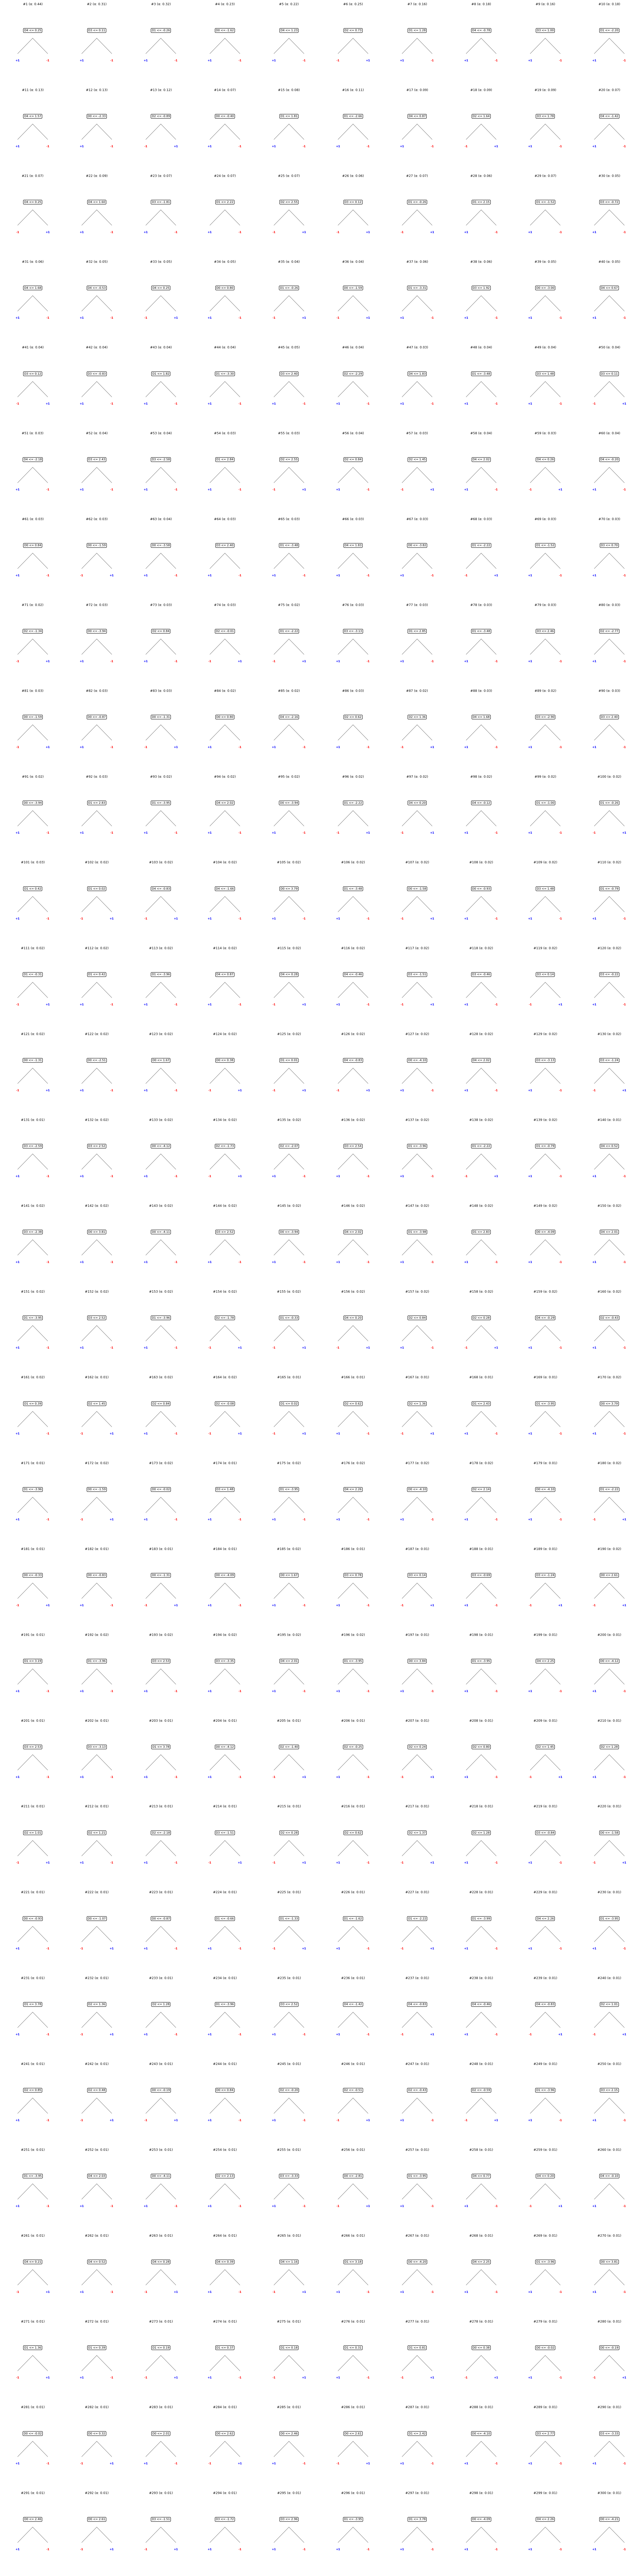

In [ ]:
n_to_show = 300 
cols = 10
rows = 30

fig, axes = plt.subplots(rows, cols, figsize=(25, 100))
axes = axes.flatten()

for i in range(n_to_show):
    f, th, p, a = models[i]
    
    axes[i].set_title(f"#{i+1} (α: {a:.2f})", fontsize=9)
    
    axes[i].text(0.5, 0.7, f"D{f} <= {th:.2f}", 
                 ha='center', va='center', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9', edgecolor='black'))
    
    left_label = "+1" if p == 1 else "-1"
    right_label = "-1" if p == 1 else "+1"
    
    axes[i].text(0.25, 0.3, left_label, ha='center', fontsize=8, 
                 color='blue' if left_label == "+1" else 'red', fontweight='bold')
    axes[i].text(0.75, 0.3, right_label, ha='center', fontsize=8, 
                 color='blue' if right_label == "+1" else 'red', fontweight='bold')
    
    axes[i].plot([0.5, 0.25], [0.6, 0.4], color='black', lw=0.5)
    axes[i].plot([0.5, 0.75], [0.6, 0.4], color='black', lw=0.5)

    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_axis_off()

plt.tight_layout()
plt.show()

Plots

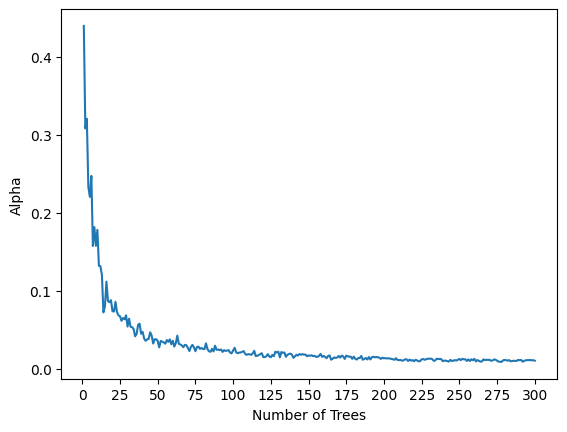

In [20]:
plt.plot(range(1,301,1), alphas)
plt.xlabel("Number of Trees")
plt.xticks([i for i in range(0,301,25)])
plt.ylabel("Alpha")
plt.show()

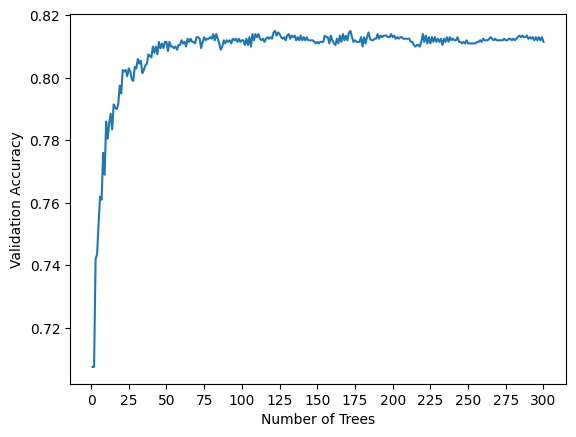

In [21]:
plt.plot(range(1,301,1), val_accuracies)
plt.xlabel("Number of Trees")
plt.xticks([i for i in range(0,301,25)])
plt.ylabel("Validation Accuracy")
plt.show()

Determining best model and test accuracy

In [22]:
# Taking first index of max val acc
# Not taking the later index due to Occam's Razor priniciple 
# And to prevent overfitting by using simpler model
best_t = np.argmax(val_accuracies) + 1

In [23]:
# Print info of best stump

best_idx = best_t - 1

best_model_params = models[best_idx]
best_train_error = train_errors[best_idx]
best_alpha = alphas[best_idx]
best_val_acc = val_accuracies[best_idx]

print(f"Best Iteration: {best_t}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Stump Training Error: {best_train_error:.4f}")
print(f"Alpha: {best_alpha:.4f}")
print(f"Stump Feature Index: {best_model_params[0]}")
print(f"Stump Threshold: {best_model_params[1]:.4f}")
print(f"Stump Polarity: {best_model_params[2]}")

Best Iteration: 122
Validation Accuracy: 0.8150
Stump Training Error: 0.4918
Alpha: 0.0163
Stump Feature Index: 0
Stump Threshold: -2.5141
Stump Polarity: 1


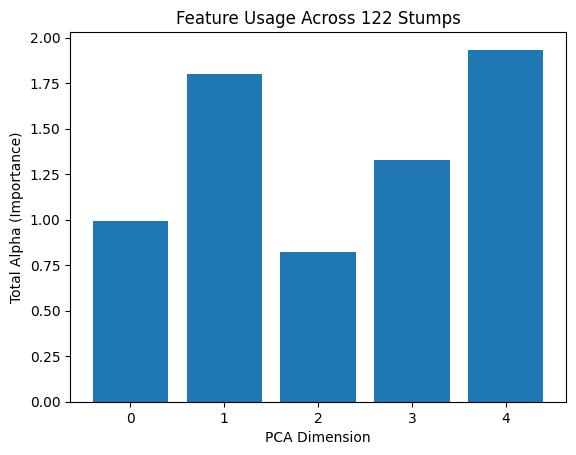

In [24]:
feature_importance = np.zeros(pca_dim) 

for i in range(best_t):
    f, th, p, a = models[i]
    feature_importance[f] += a

plt.bar(range(pca_dim), feature_importance)
plt.xlabel("PCA Dimension")
plt.ylabel("Total Alpha (Importance)")
plt.title(f"Feature Usage Across {best_t} Stumps")
plt.show()

In [25]:
test_pred = np.zeros(len(y_test))

for i in range(best_t):
    f, th, p, a = models[i]
    test_pred += a * stump_predict(X_test_5, f, th, p)

test_pred = np.sign(test_pred)
test_acc = np.mean(test_pred == y_test)

print("Best iteration:", best_t)
print(f"Test accuracy: {test_acc:.4f}")

Best iteration: 122
Test accuracy: 0.8227
